<h3 align="center"> Feature Selection Using VIF</h3>

In [9]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [6]:
df = pd.read_csv("Salaries.csv")
df.tail()

,Years of Experience,Education Level,Age,Location Factor,Salary
995,12,2,32,10,103056
996,16,2,35,10,107691
997,13,3,33,8,100478
998,19,2,40,2,100085
999,16,2,36,9,103222


In [7]:
df.shape

(1000, 5)

### Train model with all the features 

In [14]:
X = df.drop("Salary" , axis=1 , )
y = df["Salary"] 

# train test split 
x_train , x_test , y_train , y_test = train_test_split(X ,y , test_size=0.2 , random_state=10) 

model = LinearRegression()
model.fit(x_train , y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
model.score(x_test, y_test)

0.9525773624816919

In [18]:
model.coef_

array([2113.98280589, 5007.82035443, -123.21488799, 1487.64526717])

In [20]:
model.intercept_

np.float64(52608.487605282404)

In [21]:
y_test[:1]

841    151272
Name: Salary, dtype: int64

In [22]:
x_test[:1]

,Years of Experience,Education Level,Age,Location Factor
841,38,1,56,9


In [23]:
model.predict(x_test[:1])

array([144436.42826039])

In [24]:
model.intercept_+ model.coef_[0]*38	+ model.coef_[1]*1	+ model.coef_[2]*56	+ model.coef_[3]*9

np.float64(144436.42826039356)

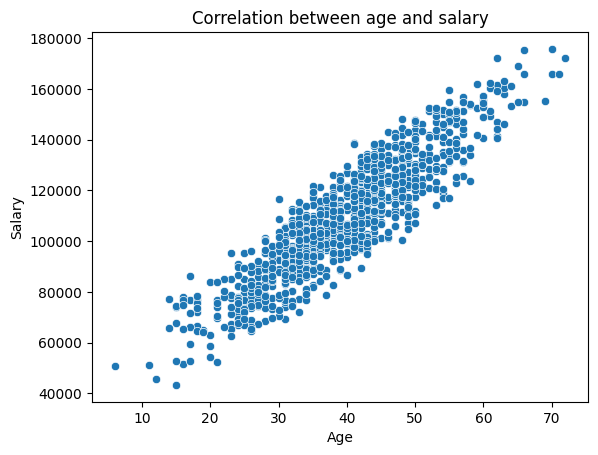

In [27]:
sns.scatterplot( df , x="Age" , y="Salary")
plt.title("Correlation between age and salary")
plt.show()

### Let's Understand Multicolinearity Using VIF

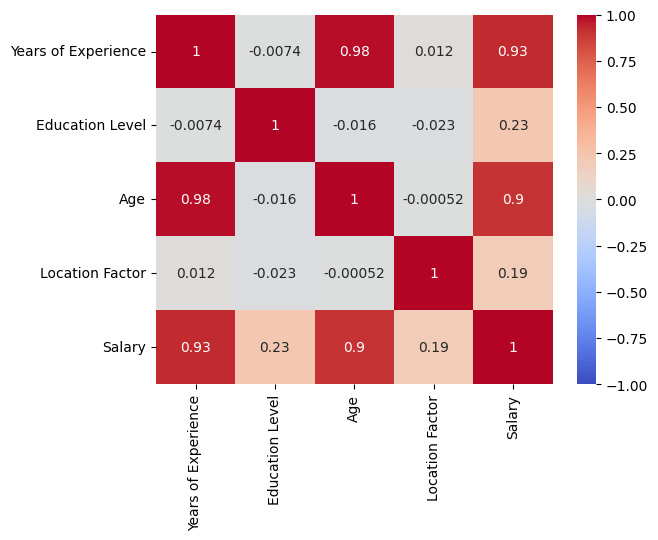

In [32]:
cm = df.corr()

sns.heatmap(cm , annot=True , cmap='coolwarm', vmin=-1, vmax=1) 
plt.show()

### Compute Variance Inflation Factor (VIF)

In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data) : 
    vif_df = pd.DataFrame()
    vif_df["variable"] = data.columns
    vif_df["vif"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif_df

In [50]:
X = df.drop('Salary', axis="columns")

calculate_vif(X)

,variable,vif
0,Years of Experience,22.342087
1,Education Level,5.472969
2,Age,42.201149
3,Location Factor,4.289467


We will start dropping columns that has VIF > 10, one column at a time

In [51]:
calculate_vif(X.drop(['Age'],axis="columns"))

,variable,vif
0,Years of Experience,3.198601
1,Education Level,3.509425
2,Location Factor,3.231181


### Train a Model With Features that are Filtered Using VIF

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X.drop("Age", axis="columns"), y, test_size=0.2, random_state=10)

model_reduced=LinearRegression()
model_reduced.fit(X_train, y_train)
model_reduced.score(X_test, y_test)

0.9523792255284542

In [53]:
model_reduced.coef_

array([1995.01818661, 5019.90803026, 1495.54971534])